## Data Understanding

This project focuses on predicting customer churn in a telecommunications company using the Telco Customer Churn dataset. Each record represents an individual customer, and the dataset contains 7043 observations with 21 features describing customer demographics, services, account information, and billing details.

### Objective

The primary goal is to build a classification model that predicts whether a customer is likely to churn (leave the company) based on historical data. This enables the business to take proactive retention actions.

### Target Variable

* **Churn**: Indicates whether the customer has left the company (Yes/No). This is a binary classification problem.

---
## Feature Categories

### 1. Customer Identification

* **customerID**: Unique identifier for each customer. This feature has no predictive value and will be removed during preprocessing.


### 2. Demographic Information

* **gender**: Customer gender (Male/Female)
* **SeniorCitizen**: Indicates if the customer is a senior citizen (1 = Yes, 0 = No)
* **Partner**: Whether the customer has a partner (Yes/No)
* **Dependents**: Whether the customer has dependents (Yes/No)

These features may influence customer stability and long-term engagement.


### 3. Customer Tenure

* **tenure**: Number of months the customer has stayed with the company

This is a key variable, as longer tenure typically indicates higher customer loyalty and lower churn probability.


### 4. Services Subscribed

* **PhoneService**: Whether the customer has phone service
* **MultipleLines**: Whether the customer has multiple lines
* **InternetService**: Type of internet service (DSL, Fiber optic, No)
* **OnlineSecurity**
* **OnlineBackup**
* **DeviceProtection**
* **TechSupport**
* **StreamingTV**
* **StreamingMovies**

These features represent the services a customer subscribes to. Customers with more services are generally more engaged and less likely to churn.


### 5. Contract and Billing Information

* **Contract**: Contract type (Month-to-month, One year, Two year)
* **PaperlessBilling**: Whether the customer uses paperless billing
* **PaymentMethod**: Payment method used by the customer

Contract type is expected to be one of the strongest predictors of churn, with short-term contracts typically associated with higher churn rates.


### 6. Financial Features

* **MonthlyCharges**: The amount charged to the customer monthly
* **TotalCharges**: The total amount charged to the customer

These features reflect the customer's financial contribution and may influence churn behavior.

---
## Initial Observations

* The dataset contains a mix of categorical and numerical features.
* Some categorical features contain redundant values such as "No internet service" or "No phone service".
* The dataset likely contains mild class imbalance in the target variable (Churn).

---
## Business Understanding

Customer churn is a critical problem in the telecom industry. Retaining existing customers is often more cost-effective than acquiring new ones. By identifying customers at risk of churning, the company can design targeted retention strategies such as personalized offers, contract adjustments, or improved service plans.

---
## Expected Key Drivers of Churn

Based on domain knowledge, the following factors are expected to significantly influence churn:

* Short contract duration (Month-to-month)
* Low tenure (new customers)
* High monthly charges
* Limited service subscriptions
* Certain payment methods (e.g., electronic check)
---

## IMPORTS & LOAD DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [48]:
df = pd.read_csv("Telecom Customer Churn Dataset.csv")

## DATA CLEANING

In [49]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [50]:
df.shape

(7043, 21)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [52]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [54]:
(df['TotalCharges'] == " ").sum()

np.int64(11)

In [55]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", None)

In [56]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [57]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [58]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [60]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [61]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [62]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("------")

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
------
gender
['Female' 'Male']
------
SeniorCitizen
[0 1]
------
Partner
['Yes' 'No']
------
Dependents
['No' 'Yes']
------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
------
PhoneService
['No' 'Yes']
------
MultipleLines
['No phone service' 'No' 'Yes']
------
InternetService
['DSL' 'Fiber optic' 'No']
------
OnlineSecurity
['No' 'Yes' 'No internet service']
------
OnlineBackup
['Yes' 'No' 'No internet service']
------
DeviceProtection
['No' 'Yes' 'No internet service']
------
TechSupport
['No' 'Yes' 'No internet service']
------
StreamingTV
['No' 'Yes' 'No internet service']
------
StreamingMovies
['No' 'Yes' 'No internet service']
------
Contract
['Month-to-month' 'One year' 'Two year']
------
PaperlessBi

In [63]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: "No", 1: "Yes"})

In [64]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='tenure'>

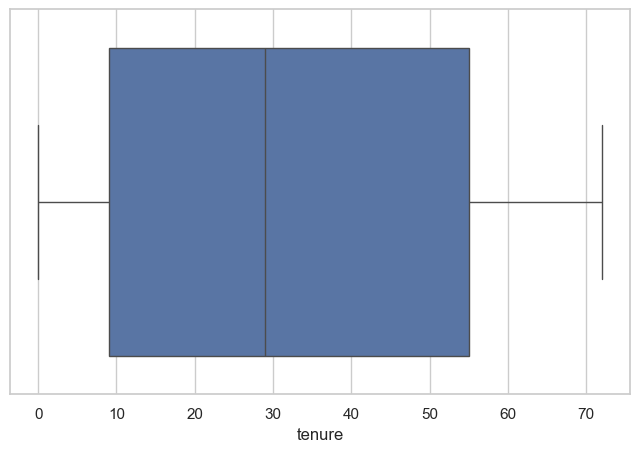

In [65]:
sns.boxplot(x=df['tenure'])

<Axes: xlabel='MonthlyCharges'>

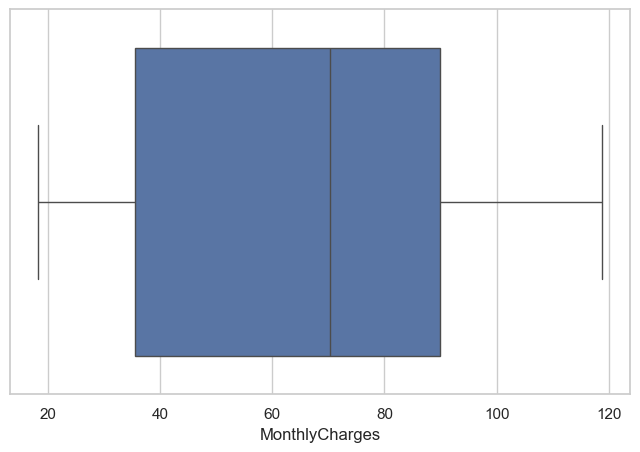

In [66]:
sns.boxplot(x=df['MonthlyCharges'])

<Axes: xlabel='TotalCharges'>

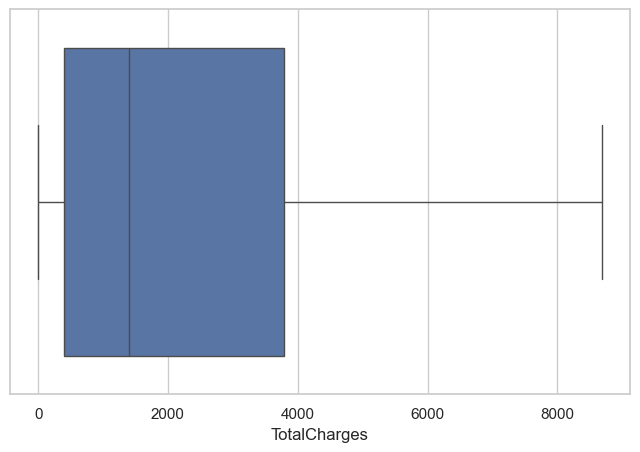

In [67]:
sns.boxplot(x=df['TotalCharges'])

In [68]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].str.strip().ne(df[col]).sum())

customerID 0
gender 0
SeniorCitizen 0
Partner 0
Dependents 0
PhoneService 0
MultipleLines 0
InternetService 0
OnlineSecurity 0
OnlineBackup 0
DeviceProtection 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
Contract 0
PaperlessBilling 0
PaymentMethod 0
Churn 0


## EDA & VISUALIZATION

In [69]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [70]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [72]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [73]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [74]:
df['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [75]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [76]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [77]:
df.groupby('Churn')['TotalCharges'].mean()

Churn
No     2549.911442
Yes    1531.796094
Name: TotalCharges, dtype: float64

In [78]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [79]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [80]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [81]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


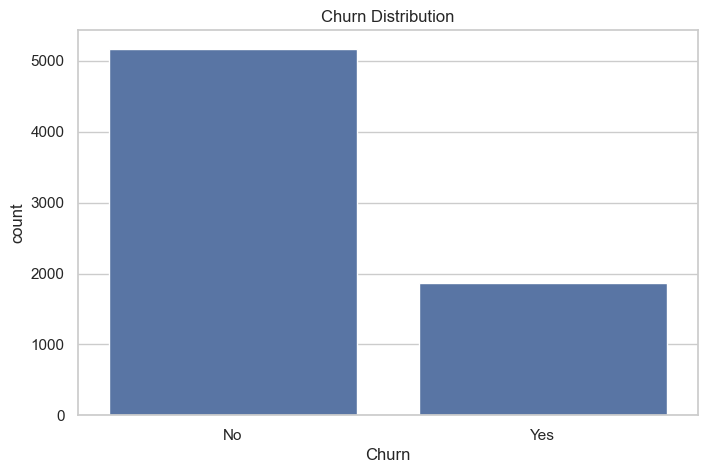

In [82]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

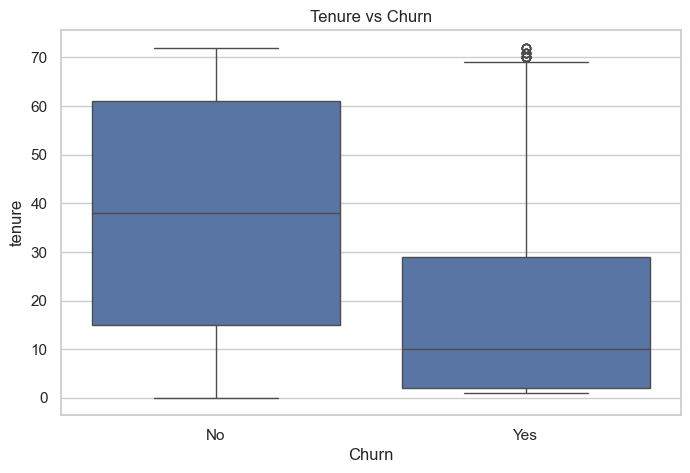

In [83]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

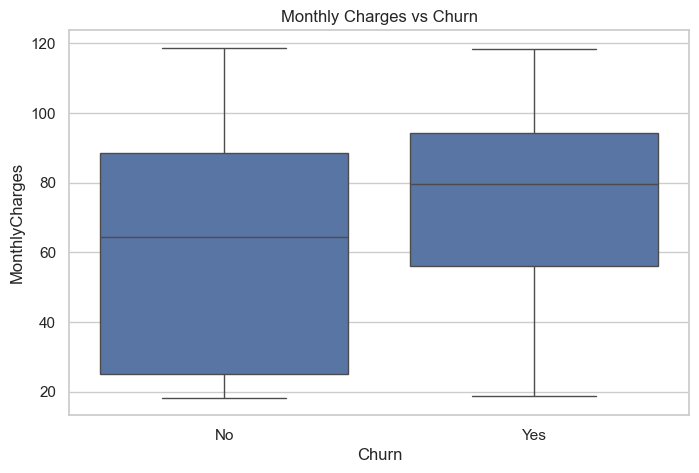

In [84]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

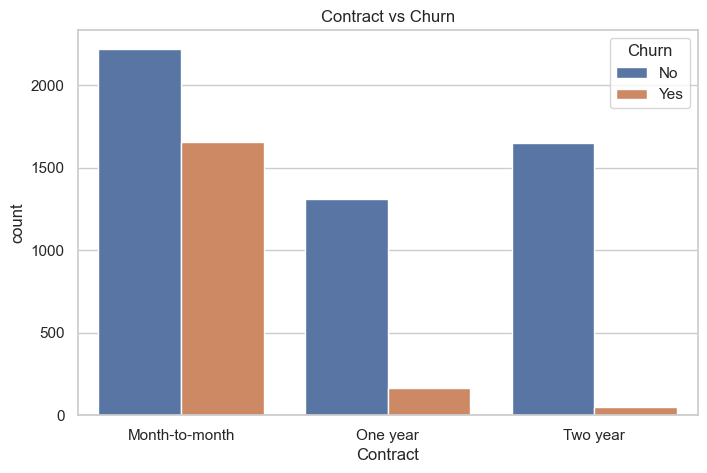

In [85]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract vs Churn")
plt.show()

In [86]:
services = ['PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

df['NumServices'] = df[services].apply(lambda x: sum(x == 'Yes'), axis=1)

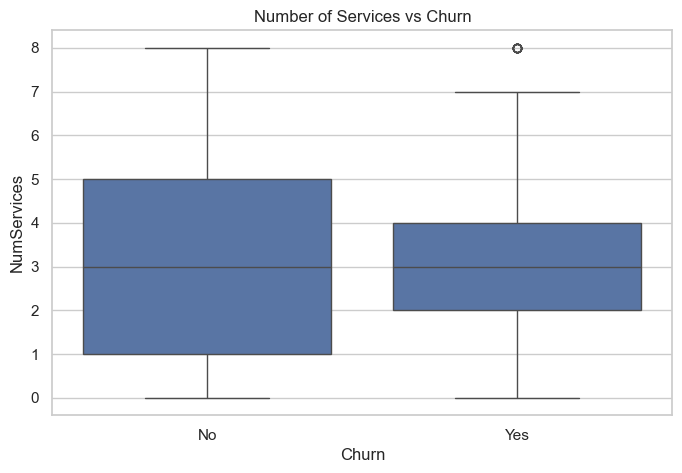

In [87]:
sns.boxplot(x='Churn', y='NumServices', data=df)
plt.title("Number of Services vs Churn")
plt.show()

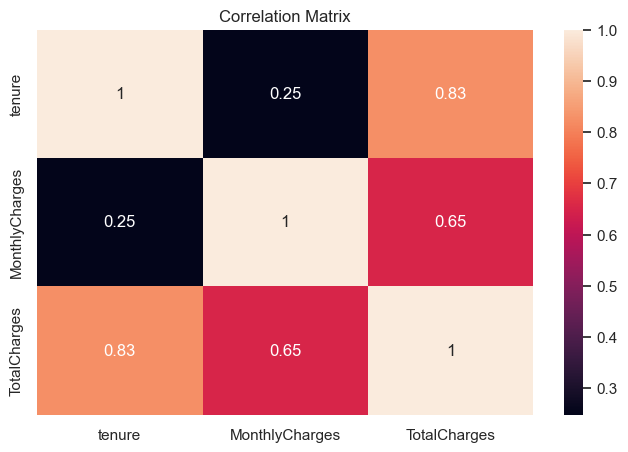

In [88]:
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()